<div style="text-align:center;">
  <h1 size=10>
    <b>DEEP LEARNING PROJECT</b><br>
    <b>WikiArt Painter Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group XX**
- Bárbar Franco (20250388)
- Catarina Mendinhas (20250422)
- Guilherme Silva (20221910)  
- Maria Carvalho (20221953)
- Maria Miguel Fonseca (20250380)

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Approach Overview](#1)
- [2. Set up & Imports](#2)
- [3. Load Dataset](#3)
- [4. Class Weights](#4)
- [5. Data Preprocessing](#5)
- [6. Modeling](#6)
    - [6.1 Basic Model Comparison](#6_1)
    - [6.2 Optimizer Comparison](#6_2)
    - [6.3 Activation Function Comparison](#6_3)



# <font color='#2f94d7' size=6>**1. Approach Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6>**2. Set up & Imports**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [ ]:
# IMPORT LIBRARIES
import os
import random
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from collections import Counter
from PIL import Image
import cv2

import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from keras.applications import EfficientNetB0, VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2XL

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import shutil
import seaborn as sns

import gc
from keras.applications import VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3


# Import .py files
from source.functions import *

2026-04-12 23:13:15.793014: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# GENERAL CONFIGURATION
AUTOTUNE    = tf.data.AUTOTUNE
output_dir = "figures"

print('Keras  :', keras.__version__)
print('TF     :', tf.__version__)
print('GPU    :', tf.config.list_physical_devices('GPU') or 'None - CPU mode')

Keras  : 3.13.2
TF     : 2.16.2
GPU    : None - CPU mode


# <font color='#2f94d7' size=6>**3. Load Dataset**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [4]:
# DATASET CONFIGURATION
IMG_SIZE    = (512, 512)   # Initial image size (can be adapted later for modeling)
NUM_CLASSES = 23
BATCH_SIZE  = 32 

SPLIT_DIR      = Path('wikiart_split')
train_dir_path = SPLIT_DIR / 'train'
val_dir_path   = SPLIT_DIR / 'val'
test_dir_path  = SPLIT_DIR / 'test'

In [ ]:
# LOAD DATASETS FROM THE SPLIT FOLDERS 
# image_dataset_from_directory infers labels from subfolder names,
# guaranteeing consistent class_names order across machines.

train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir_path,
    label_mode='int', # integer labels for multi-class classification with class weights
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    verbose=False
) # shuffle is True by default, which is good for training

val_ds_raw = keras.utils.image_dataset_from_directory(
    val_dir_path,
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir_path,
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

class_names = train_ds_raw.class_names

In [6]:
print(f"Class names: {class_names}")

# Check if labels are correctly inferred (one-hot encoded)
for images, labels in train_ds_raw.take(1):
    print(labels.shape)
    print(labels[0])

Class names: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']
(32, 23)
tf.Tensor([0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.], shape=(23,), dtype=float32)


2026-04-12 23:13:43.807385: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# <font color='#2f94d7' size=6>**4. Class Weights**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [ ]:
# Compute class weights to handle class imbalance

# Extract labels from training dataset (convert one-hot → class index)
train_labels_flat = np.concatenate([
    y.numpy() for _, y in train_ds_raw
])

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_flat
)

# Convert to dictionary format required by Keras
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}

# Display classes with highest weights (rarest classes)
print("Class weights (top 5 heaviest):")
sorted_cw = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)

for idx, w in sorted_cw[:5]:
    print(f"  {class_names[idx]:<10}: {w:.3f}")

Class weights (top 5 heaviest):
  Salvador_Dali: 1.726
  Raphael_Kirchner: 1.599
  Ivan_Shishkin: 1.593
  Ilya_Repin: 1.531
  Childe_Hassam: 1.515


2026-04-12 23:14:10.999685: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


As expected, artists with fewer paintings receive higher class weights. This ensures that misclassifications on these underrepresented classes are penalized more during training, helping to reduce the impact of class imbalance.

# <font color='#2f94d7' size=6>**5. Data Preprocessing**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

In [ ]:
# DEFINE AND APPLY DATA AUGMENTATION
base_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),       # ~ ±10°
    layers.RandomTranslation(0.03, 0.03),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
], name="base_augmentation")

train_aug = (train_ds_raw
    .shuffle(1000, seed=SEED)
    .map(lambda x, y: (base_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))
# train_aug is not a dataset that is stored in memory, but a transformation pipeline applied on-the-fly to the training dataset.
# every time train_aug is iterated over, the base_augmentation transformations are applied to the images in train_ds_raw in a randomized manner, creating augmented versions of the images on-the-fly during training.
# loads 1000 samples into a shuffle buffer, shuffles them, and then applies the augmentation transformations to each batch of images as they are fed into the model during training.

In [ ]:
# VISUALISE AUGMENTED TRAINING SAMPLES
sample_imgs, sample_labels = next(iter(train_aug)) # first batch of augmented images

# assert that the augmented images are still in the expected range and format
print(sample_imgs.dtype)
print(tf.reduce_min(sample_imgs), tf.reduce_max(sample_imgs))

2026-04-12 23:14:22.510999: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 34 of 1000
2026-04-12 23:14:37.967300: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 57 of 1000
2026-04-12 23:14:55.565096: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 116 of 1000
2026-04-12 23:15:37.926255: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 131 of 1000
2026-04-12 23:16:00.105193: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 145 of 1000
2026-04-12 23:16:15.030990: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a wh

<dtype: 'float32'>
tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(255.0, shape=(), dtype=float32)


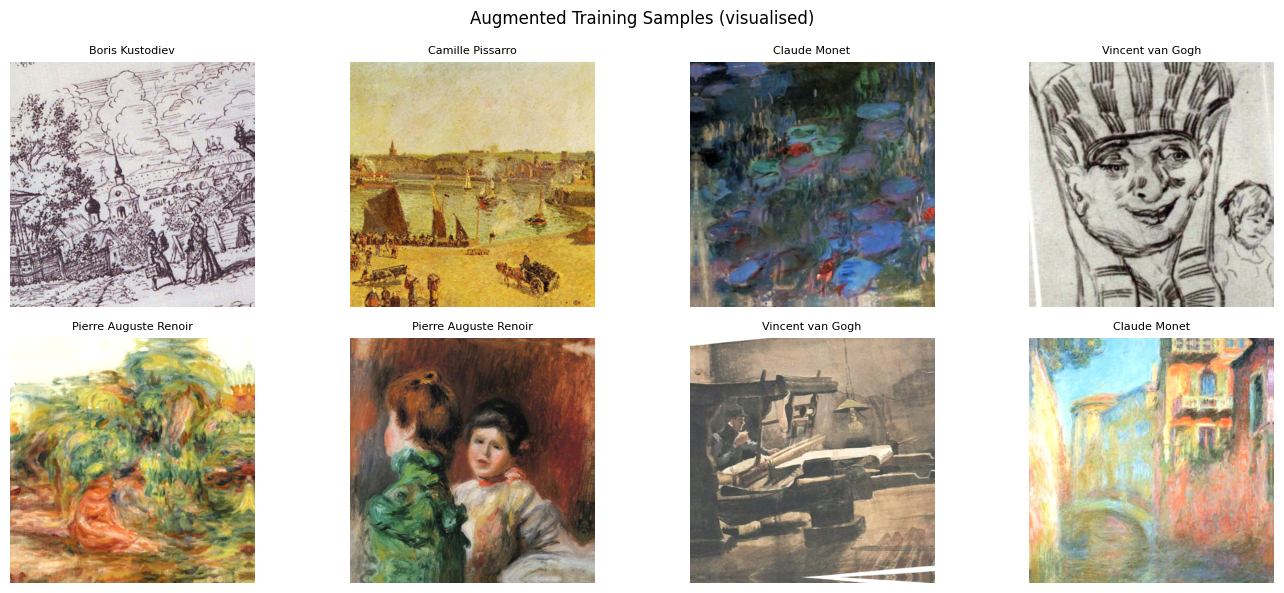

In [10]:
# imshow expects images in [0, 1] for floats, so we scale down the pixel values for visualization.
sample_display = sample_imgs[:8].numpy() / 255.0

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img, lbl in zip(axes.flatten(), sample_display, sample_labels[:8]):
    ax.imshow(img)
    ax.set_title(class_names[np.argmax(lbl)].replace('_', ' '), fontsize=8)
    ax.axis('off')
    
plt.suptitle('Augmented Training Samples (visualised)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "augmented_samples.png"), dpi=150)
plt.show()

In [ ]:
# RESIZE DATASETS TO DIFFERENT SIZES
def build_resized_ds(train_ds, val_ds, image_model_size):
    def resize_fn(image, label):
        image = tf.image.resize(image, [image_model_size, image_model_size])
        return image, label

    train_ds = train_ds.map(resize_fn, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.map(resize_fn, num_parallel_calls=AUTOTUNE)

    return train_ds, val_ds

# we create separate resized datasets for each image size we want to experiment with during modeling.
train_224, val_224 = build_resized_ds(train_aug, val_ds_raw, 224)
train_300, val_300 = build_resized_ds(train_aug, val_ds_raw, 300)
train_512, val_512 = build_resized_ds(train_aug, val_ds_raw, 512)


In [12]:
# DEF PREPROCESSING FUNCTION FOR DIFFERENT MODELS
def apply_preprocess_ds(train_resized, val_resized, preprocess_fn, batch_size=32):
    def apply_preprocess_img(image, label):
        image = preprocess_fn(image)
        return image, label

    t_ds = (train_resized
            .shuffle(len(train_resized), seed=SEED)
            .map(apply_preprocess_img, num_parallel_calls=AUTOTUNE)
            .batch(batch_size)
            .prefetch(AUTOTUNE))
    v_ds = (val_resized
            .map(apply_preprocess_img, num_parallel_calls=AUTOTUNE)
            .batch(batch_size)
            .prefetch(AUTOTUNE))
    return t_ds, v_ds

# <font color='#2f94d7' size=6>**6. Modeling**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

In [13]:
# METRICS - USED IN MODEL EVALUATION AND COMPARISON
def make_metrics():
    return [
        keras.metrics.F1Score(
            average='macro',
            name='macro_f1'
        ),
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy'),
    ]

# <font color='#2f94d7' size=6>**6.1 Basic Model Comparison**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

To understand how architecture affects performance on artistic style classification, we compare **six backbones** using the same training pipeline (Phase 1 only — frozen backbone, identical head and hyperparameters).

| Backbone | Why include it? |
|---|---|
| **EfficientNetB0** | Our primary model — compound-scaled CNN, strong accuracy/size ratio |
| **VGG16** | Classic deep CNN — large but historically strong on texture/style tasks |
| **ResNet50V2** | Residual connections baseline — widely used reference point |
| **ConvNeXt-Tiny** | Modern pure-CNN (2022) — incorporates Transformer design ideas into a CNN, often outperforms EfficientNets |
| **EfficientNetB3** | More complex version of EfficientNetB0, expects 300x300 sized images|
| **EfficientNetV2XL** | Expects 512x512 sized images (the size of our raw images), is very computanionally heavy|


All models use ImageNet pretrained weights. We train only the classification head (frozen backbone) for a fixed number of epochs to ensure a fair comparison. The best `val_macro_f1` from each run is recorded.  

We will use the class weights we defined earlier. In this initial phase of testing we will use a simple model (only one Dense intermideate layer) for efficiency and to check which models are more adequate for our data.

In [ ]:
# BACKBONE CONFIGS - DEFINES THE BACKBONE MODELS, THEIR PREPROCESSING FUNCTIONS AND THE IMAGE SIZE THEY REQUIRE
BACKBONE_CONFIGS = {
    'EfficientNetB0': {
        'model_fn': EfficientNetB0,
        'preprocess': keras.applications.efficientnet.preprocess_input,
        'image_size': (224, 224)
    },
    'EfficientNetB3': {
        'model_fn': EfficientNetB3,
        'preprocess': keras.applications.efficientnet.preprocess_input,
        'image_size': (300, 300)
    },
    'VGG16': {
        'model_fn': VGG16,
        'preprocess': keras.applications.vgg16.preprocess_input,
        'image_size': (224, 224)
    },
    'ResNet50V2': {
        'model_fn': ResNet50V2,
        'preprocess': keras.applications.resnet_v2.preprocess_input,
        'image_size': (224, 224)
    },
    'ConvNeXtTiny': {
        'model_fn': ConvNeXtTiny,
        'preprocess': keras.applications.convnext.preprocess_input,
        'image_size': (224, 224)
    },
}

In [ ]:
def build_base_model(backbone_name):
    backbone_config = BACKBONE_CONFIGS.get(backbone_name)
    if not backbone_config:
        raise ValueError(f"Backbone '{backbone_name}' not found in configs.")

    backbone_fn = backbone_config['model_fn']
    IMG_SIZE = backbone_config['image_size']

    bb = backbone_fn(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3)
    )
    bb.trainable = False

    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x   = bb(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out), bb

In [ ]:
# ── Comparison loop ─────────────────────────────────────────────────────────
comparison_results = {}

# PRECISO DE ASSOCIAR O VAL E TRAIN  RESIZED A CADA BACKBONE E 

for name, cfg in BACKBONE_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'  Training {name}')
    print(f'{"="*60}')

    comp_model, comp_bb = build_comparison_model(cfg['model_fn'])
    comp_train, comp_val = make_pipeline_no_aug(cfg['preprocess'])

    n_params   = comp_model.count_params()
    trainable  = sum(tf.size(w).numpy() for w in comp_model.trainable_weights)
    print(f'  Parameters : {n_params:,} total | {trainable:,} trainable')

    comp_model.compile(
        optimizer=optimizers.Adam(learning_rate=PHASE1_LR),
        loss='sparse_categorical_crossentropy',
        metrics=make_metrics()
    )

    hist = comp_model.fit(
        comp_train,
        epochs=COMPARE_EPOCHS,          # 20-25
        validation_data=comp_val,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=ES_PATIENCE_P1,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=LR_FACTOR,
                patience=LR_PATIENCE_P1,
                min_lr=LR_MIN_P1,
                verbose=1
            ),
        ], # ADICIONAR MODEL CHECKPOINT E TENSORBOARD
        verbose=1
    )

    comparison_results[name] = {
        'params':       n_params,
        'trainable':    trainable,
        'best_val_f1':  max(hist.history['val_macro_f1']),
        'best_val_top3': max(hist.history['val_top3_accuracy']),
        'min_val_loss': min(hist.history['val_loss']),
        'history':      hist.history,
    }

    print(f'  Best val macro F1 : {comparison_results[name]["best_val_f1"]:.4f}')
    print(f'  Best val top-3    : {comparison_results[name]["best_val_top3"]:.4f}')
    print(f'  Min val loss      : {comparison_results[name]["min_val_loss"]:.4f}')

    # ── Libertar memória GPU antes do próximo backbone ──
    del comp_model, comp_bb
    keras.backend.clear_session()
    gc.collect()

# <font color='#2f94d7' size=6>**6.2 Optmizer Comparison**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6>**6.3 Activation Function Comparison**</font> <a class="anchor" id="6_3"></a>

[Back to TOC](#toc)